# Customer Purchase Analysis for a Fashion Retailer  

### Description:  
Hey friend, imagine you're a data analyst for a popular fashion retailer, and you need to analyze customer purchase behavior. The company wants to understand which products are frequently bought together, identify trends in customer purchases and preferences, and optimize marketing strategies accordingly.  

### Tasks:  
- **Product Category Optimization:** Merge two datasets (customer purchases and product categories) to identify which product categories have the highest average order value.  
- **Product Analysis:** Create a summary table to identify and display the top-selling product (ranked #1) for each month of every year.
- **Customer Purchase Trends:** Transform the data to show the monthly purchase trends for each customer segment (e.g., age group, location). Use grouping and aggregation to calculate average monthly purchases.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import sys

print('Python version ' + sys.version)
print('Pandas version ' + pd.__version__)
print('Numpy version ' + np.__version__)

Python version 3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]
Pandas version 2.2.1
Numpy version 1.26.4


# The Data  

This dataset represents a fashion retailer's customer purchase behavior, consisting of approximately 5,000 purchases made by 1,000 customers across 50 products, with details on customer demographics, product information and purchase history. The data includes customer ID, age, location, product ID, product name, category, purchase date and order value.  

### Columns:  
- **CustomerID:** Unique customer identifier.
- **Age:** Customer age.
- **Location:** Customer location (Urban/Rural).
- **ProductID:** Unique product identifier.
- **ProductName:** Product name (18-64 years of age)
- **Category:** Product category (Clothing/Accessories/Footwear).
- **PurchaseID:** Unique purchase identifier.
- **PurchaseDate:** Date of purchase.
- **OrderValue:** Total value of the purchase.

In [2]:
# set the seed
np.random.seed(0)

# customer data
customer_data = pd.DataFrame({
    'CustomerID': np.arange(1, 1001),
    'Age': np.random.randint(18, 65, 1000),
    'Location': np.random.choice(['Urban', 'Rural'], 1000)
})

# product data
product_data = pd.DataFrame({
    'ProductID': np.arange(1, 51),
    'ProductName': [f'Product {i}' for i in range(1, 51)],
    'Category': np.random.choice(['Clothing', 'Accessories', 'Footwear'], 50)
})

# purchase data
purchase_data = pd.DataFrame({
    'PurchaseID': np.arange(1, 5001),
    'CustomerID': np.random.choice(customer_data['CustomerID'], 5000),
    'ProductID': np.random.choice(product_data['ProductID'], 5000),
    'PurchaseDate': pd.date_range('2022-01-01', periods=5000),
    'OrderValue': np.random.randint(10, 100, 5000)
})

Let us take a look at the data types for each dataframe.

In [3]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CustomerID  1000 non-null   int32 
 1   Age         1000 non-null   int32 
 2   Location    1000 non-null   object
dtypes: int32(2), object(1)
memory usage: 15.8+ KB


In [4]:
product_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ProductID    50 non-null     int32 
 1   ProductName  50 non-null     object
 2   Category     50 non-null     object
dtypes: int32(1), object(2)
memory usage: 1.1+ KB


In [5]:
purchase_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   PurchaseID    5000 non-null   int32         
 1   CustomerID    5000 non-null   int32         
 2   ProductID     5000 non-null   int32         
 3   PurchaseDate  5000 non-null   datetime64[ns]
 4   OrderValue    5000 non-null   int32         
dtypes: datetime64[ns](1), int32(4)
memory usage: 117.3 KB


# Product Category Optimization  

Merge two datasets (customer purchases and product categories) to identify which product categories have the highest average order value. Use data reshaping to present the results.

> **Note:** the `.merge()` method performs an inner join by default. This means only the rows where "ProductID" matches between the two dataframes will be returned.

In [7]:
# merge the product and purchase dataframes
df = purchase_data.merge(product_data, on='ProductID')
df.head()

,PurchaseID,CustomerID,ProductID,PurchaseDate,OrderValue,ProductName,Category
0,1,525,8,2022-01-01,25,Product 8,Accessories
1,2,430,10,2022-01-02,31,Product 10,Footwear
2,3,520,40,2022-01-03,53,Product 40,Clothing
3,4,507,46,2022-01-04,92,Product 46,Footwear
4,5,432,34,2022-01-05,20,Product 34,Footwear


In [8]:
# create group object
group = df.groupby('Category')

# get the average OrderValue of group
group['OrderValue'].mean().sort_values(ascending=False)

Category
Accessories    55.083221
Footwear       55.024229
Clothing       54.106714
Name: OrderValue, dtype: float64

# Product Analysis  

Create a summary table to identify and display the top-selling product (ranked #1) for each month of every year.  

**Note:** The tricky piece to this task is that after we group by the month-year and count the number of products sold suring that time period, we need to select the top-selling product. Grouping and then counting that group is the easy part. Selecting n number of rows from that group is the part that is a little harder to do. 

To convert a date object into `YYYY-MONTH`, use:   
* `%Y` - Extract the year
* `%B` - Extract the full month name

In [13]:
df['PurchaseDate'][:5].dt.strftime('%Y-%B')

0    2022-January
1    2022-January
2    2022-January
3    2022-January
4    2022-January
Name: PurchaseDate, dtype: object

In [21]:
# create year_month column
df['year_month'] = df['PurchaseDate'].dt.strftime('%Y-%B')
df.head()

,PurchaseID,CustomerID,ProductID,PurchaseDate,OrderValue,ProductName,Category,year_month
0,1,525,8,2022-01-01,25,Product 8,Accessories,2022-January
1,2,430,10,2022-01-02,31,Product 10,Footwear,2022-January
2,3,520,40,2022-01-03,53,Product 40,Clothing,2022-January
3,4,507,46,2022-01-04,92,Product 46,Footwear,2022-January
4,5,432,34,2022-01-05,20,Product 34,Footwear,2022-January


The first step is to create a new dataset that has the frequency each "ProductName" shows up in a specific Year-Month combination. Remember these products represents sales made on that particular date.  

Here is a summary of what we are doing in the code below:  
- Create a group object that includes the "year_month" and "ProductName" columns  
- We then count the number of times the product was sold on that "year_month" using `count()`  
- Since the dataframe has multiple columns, I just picked "PurchaseID". The rest of the columns should all have the same values  
- `.reset_index` is used so the columns "year_month" and "ProductName" are moved from the index into a regular dataframe column
- I then renamed the "PurchaseID" column to "count" as that is what it represents

We end up with a new dataset that tells us how many times a specific product was sold the month of every year.

In [120]:
# group by year-month and ProductName
group = df.groupby(['year_month', 'ProductName'])

# generate the ProductName frequency dataset
year_month_df = group.count()['PurchaseID'] \
                     .reset_index() \
                     .rename(columns={'PurchaseID': 'count'})

year_month_df.head()

,year_month,ProductName,count
0,2022-April,Product 1,1
1,2022-April,Product 10,1
2,2022-April,Product 11,1
3,2022-April,Product 13,3
4,2022-April,Product 22,2


Now we can grab the top-selling product on a particular date. We clean up the data a bit so that at the end we end up with the specific "id" that will point to the name of the Product we are after.

Let me explain what this "id" column represents:  
The dataframe named "year_month_df" contains an index. Do you see it? Every row contains an index value and this index value is what we see in the dataframe named "n_largest". 

If we take the first row, we see a value of 3 under the "id" column. This value of 3 is pointing to the row in the "year_month_df" dataframe that has an index value of 3.
- This means the row: `2022-April, Product 13, 3`

We then will end up with a dataframe named "n_largest" that has all of the top-selling Products for a specific year-month combination. For those curious, you can update `nlargest(1)` to any other number to get for example the top 2 selling products.

In [121]:
n_largest = year_month_df.groupby('year_month')['count'] \
                         .nlargest(2) \
                         .reset_index()[['year_month','level_1']] \
                         .rename(columns={'level_1': 'id'})
n_largest.head()

,year_month,id
0,2022-April,3
1,2022-April,17
2,2022-August,33
3,2022-August,22
4,2022-December,57


We then use the `.merge()' method to lookup the "ProductName" associated with the "id" column.

In [122]:
results = year_month_df.merge(n_largest, left_index=True, right_on='id')[['year_month_x','ProductName']]
results.head()

,year_month_x,ProductName
0,2022-April,Product 13
1,2022-April,Product 50
3,2022-August,Product 20
2,2022-August,Product 33
5,2022-December,Product 20


Another simpler approach might be to simply sort the data and use the `.head(n)` method.

In [119]:
def get_top_n(df, n):
    return df.sort_values(['year_month', 'count'], ascending=[True, False]) \
             .groupby('year_month').head(n).reset_index(drop=True)    

# group by year-month and ProductName
group = df.groupby(['year_month', 'ProductName'])

# generate the ProductName frequency dataset
year_month_df = group.count()['PurchaseID'] \
                     .reset_index() \
                     .rename(columns={'PurchaseID': 'count'}) \
                     .pipe(get_top_n, 1)

year_month_df.head()

,year_month,ProductName,count
0,2022-April,Product 13,3
1,2022-August,Product 33,3
2,2022-December,Product 39,3
3,2022-February,Product 20,2
4,2022-January,Product 27,3


# Customer Purchase Trends  

Transform the data to show the monthly purchase trends for each customer segment (e.g., age group, location). Use grouping and aggregation to calculate average monthly purchases.

In [124]:
# merge the customer, product and purchase dataframes
df = purchase_data.merge(product_data, on='ProductID') \
                  .merge(customer_data, on='CustomerID')
df.head()

,PurchaseID,CustomerID,ProductID,PurchaseDate,OrderValue,ProductName,Category,Age,Location
0,1,525,8,2022-01-01,25,Product 8,Accessories,24,Rural
1,2,430,10,2022-01-02,31,Product 10,Footwear,18,Urban
2,3,520,40,2022-01-03,53,Product 40,Clothing,50,Urban
3,4,507,46,2022-01-04,92,Product 46,Footwear,39,Rural
4,5,432,34,2022-01-05,20,Product 34,Footwear,54,Urban


In [128]:
# create year_month column
df['year_month'] = df['PurchaseDate'].dt.strftime('%Y-%m')
df.head()

,PurchaseID,CustomerID,ProductID,PurchaseDate,OrderValue,ProductName,Category,Age,Location,year_month
0,1,525,8,2022-01-01,25,Product 8,Accessories,24,Rural,2022-01
1,2,430,10,2022-01-02,31,Product 10,Footwear,18,Urban,2022-01
2,3,520,40,2022-01-03,53,Product 40,Clothing,50,Urban,2022-01
3,4,507,46,2022-01-04,92,Product 46,Footwear,39,Rural,2022-01
4,5,432,34,2022-01-05,20,Product 34,Footwear,54,Urban,2022-01


In [171]:
# create group object
object = df.groupby(['year_month','Location'])

# calculate average monthly purchases on the group
result = object['OrderValue'].mean()
result.head()

year_month  Location
2022-01     Rural       57.857143
            Urban       64.117647
2022-02     Rural       51.500000
            Urban       50.500000
2022-03     Rural       42.615385
Name: OrderValue, dtype: float64

We can see that "Rural" customers seem to have higher orders than "Urban" customers. 

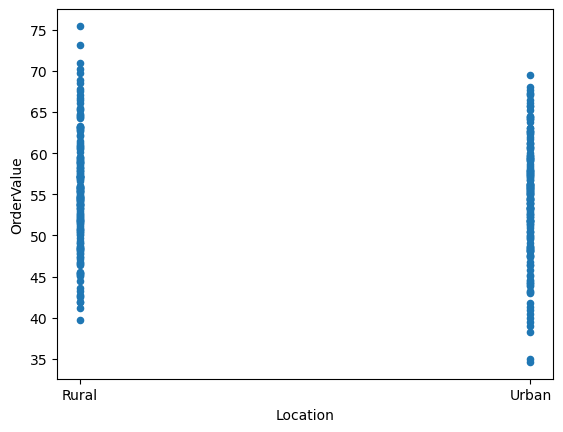

In [175]:
result.reset_index().plot.scatter(x='Location',y='OrderValue');

In [176]:
# create group object
object = df.groupby(['year_month','Age'])

# calculate average monthly purchases on the group
result = object['OrderValue'].mean()
result.head()

year_month  Age
2022-01     18     64.333333
            20     73.000000
            21     80.000000
            22     85.000000
            24     25.000000
Name: OrderValue, dtype: float64

No patterns identified for the customers ages.

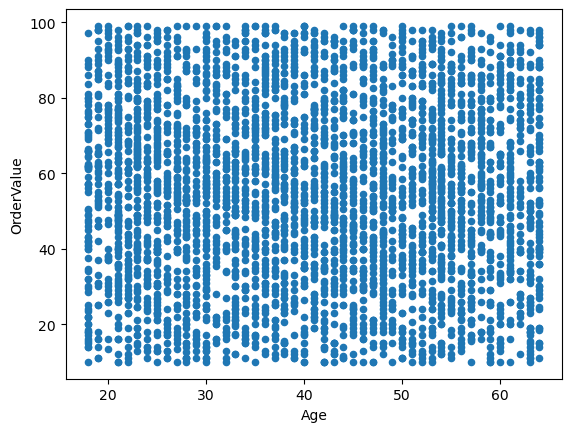

In [177]:
result.reset_index().plot.scatter(x='Age',y='OrderValue');

If we take a look at the year 2022 as a sample of the dataset, I am not able to see any trends in the data.

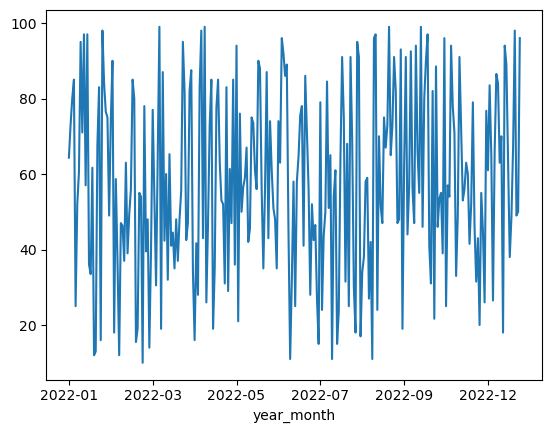

In [188]:
result.reset_index().set_index('year_month')[:'2022-12']['OrderValue'].plot();

# Summary  

You have gained hands-on experience analyzing customer purchase behavior for a fashion retailer using Pandas.  

### Key Skills Acquired
- Merge datasets
- Group and aggregate data
- Visualize trends
- Identify patterns in customer purchasing behavior

You can now apply these skills to real-world data analysis tasks, uncovering valuable insights in customer behavior and preferences.  

### Key Takeaways
- Merging datasets using `pd.merge()`.
- Grouping and aggregating data using `groupby()` and `mean()`.
- Reshaping data using `reset_index()` and `rename()`.
- Filtering top-selling products using `nlargest()` or `sort_values()` and `head()`.
- Visualizing data using `plot.scatter()`.

<p class="text-muted">This tutorial was created by <a href="https://www.hedaro.com" target="_blank"><strong>HEDARO</strong></a></p>